In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:
df = pd.read_pickle('track_length_iou_estimation.pkl')

In [8]:
pdf = df.groupby(['species', 'name']).apply(lambda x: pd.Series(np.gradient(x['iou'], x['total_l2_path']), x['total_l2_path'])).reset_index()
pdf = pdf.rename(columns={0:'pdf'})

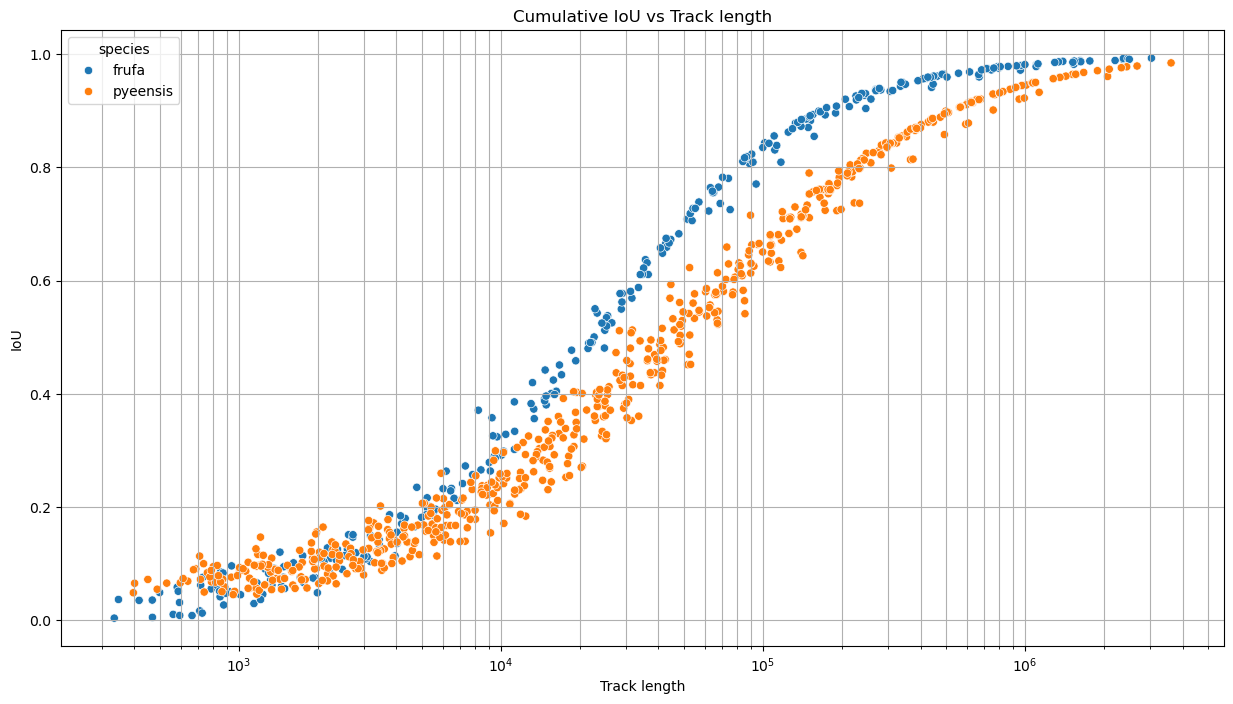

In [ ]:
plt.figure(figsize=(15, 8))
sns.scatterplot(data=df, x='total_l2_path', y='iou', hue='species')
plt.title('Cumulative IoU vs Track length')
plt.xlabel('Track length')
plt.ylabel('IoU')
plt.xscale('log')
# plt.yscale('log')
plt.grid(which='both')
# plt.savefig('cdf_iou_track_length_seaborn.png')
plt.show()

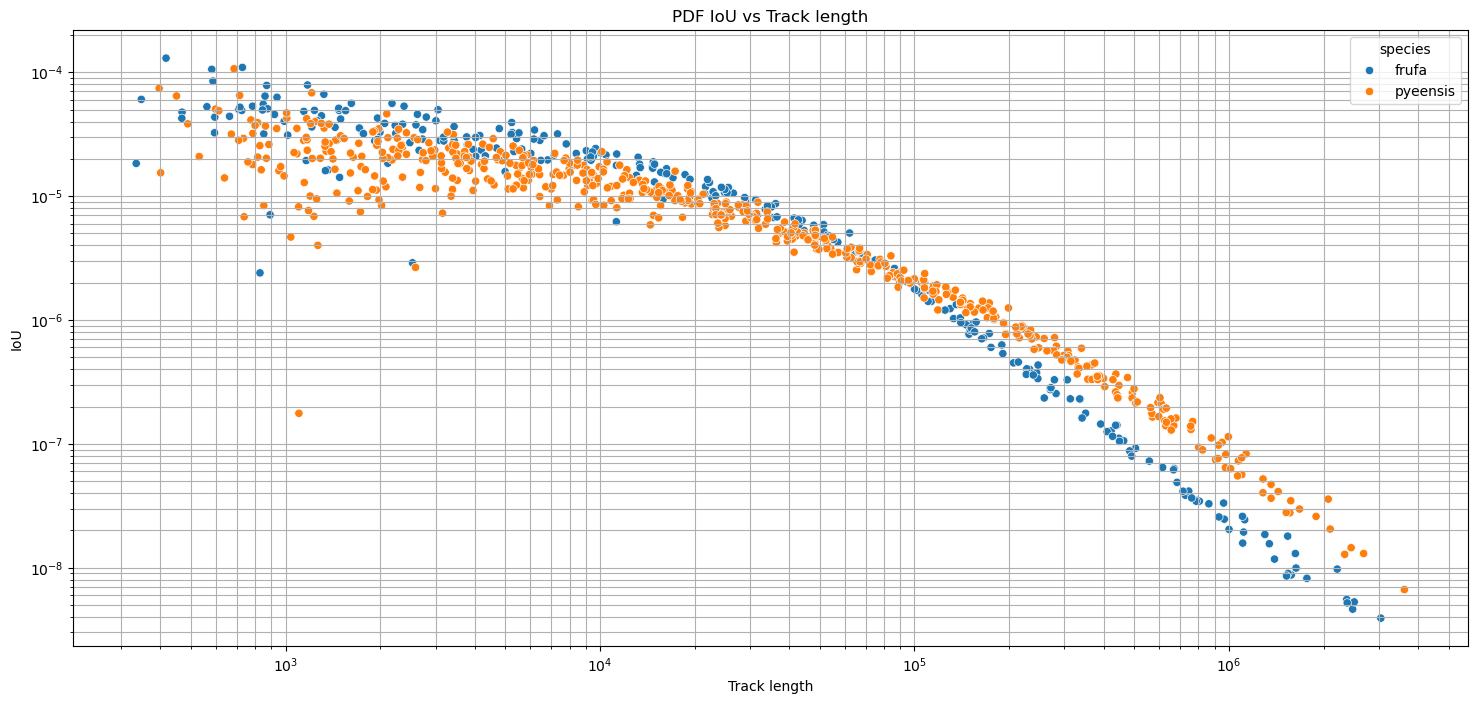

In [60]:
plt.figure(figsize=(18, 8))
sns.scatterplot(data=pdf, x='total_l2_path', y='pdf', hue='species')
plt.title('PDF IoU vs Track length')
plt.xlabel('Track length')
plt.ylabel('IoU')
plt.xscale('log')
plt.yscale('log')
plt.grid(which='both')
# plt.savefig('pdf_iou_track_length_seaborn.png')
plt.show()

In [67]:
fig = px.scatter(df, x='total_l2_path', y='iou', color='species', log_x=True, log_y=True, height=600, width=1500)
fig.update_layout(
    title='CDF IoU vs Track length',  
    xaxis_title='Frames',             
    yaxis_title='IoU',                                    
    legend_title='Species',                           
    font=dict(size=14),                                 
    title_font_size=16
                                   
)

fig.show()
# fig.write_html('cdf_iou.html')

In [ ]:
fig = px.scatter(pdf, x='total_l2_path', y='pdf', color='species', log_x=True, log_y=True, height=600, width=1500)
fig.update_layout(
    title='PDF IoU vs Track length',  
    xaxis_title='Frames',             
    yaxis_title='PDF',                                    
    legend_title='Track length',                           
    font=dict(size=14),                                 
    title_font_size=16
                                   
)

fig.show()
# fig.write_html('cdf_iou.html')